In [3]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, roc_auc_score)
import matplotlib.pyplot as plt
import DecompensationImputed

## Data (with missingness indicators)

In [4]:
X, y, groups = DecompensationImputed.load_data(
    sample_size=10000, icu_vitals=True, top_n_labs=230, top_n_drugs=954,
    top_n_procedures=55, step_hours=48, missingness_indicators=True
)

Loading from cache: decomp_rolling_n10000_v1_l230_d954_p55_o48_pred24_s48_miss
Returning 45820 windows with 863 features. y distribution:
y
0    0.945941
1    0.054059
Name: proportion, dtype: float64


In [5]:
# Drop one feature from each pair with |correlation| > 0.8
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.8)]

for col in to_drop:
    correlated_with = upper.index[upper[col] > 0.8].tolist()
    print(f"  Dropping {col:45s} (corr > 0.8 with {correlated_with})")

X = X.drop(columns=to_drop)
print(f"\nDropped {len(to_drop)} features, {X.shape[1]} remaining")

  Dropping lab_asparate_aminotransferase_(ast)           (corr > 0.8 with ['lab_alanine_aminotransferase_(alt)'])
  Dropping lab_eag                                       (corr > 0.8 with ['lab_%_hemoglobin_a1c'])
  Dropping lab_hemoglobin                                (corr > 0.8 with ['lab_hematocrit'])
  Dropping lab_mcv                                       (corr > 0.8 with ['lab_mch'])
  Dropping lab_n2_gene_ct                                (corr > 0.8 with ['lab_e_gene_ct'])
  Dropping lab_n2_gene_endpt                             (corr > 0.8 with ['lab_e_gene_ct', 'lab_n2_gene_ct'])
  Dropping lab_pt                                        (corr > 0.8 with ['lab_inr(pt)'])
  Dropping lab_red_blood_cells                           (corr > 0.8 with ['lab_hematocrit', 'lab_hemoglobin'])
  Dropping lab_required_o2                               (corr > 0.8 with ['lab_alveolar-arterial_gradient'])
  Dropping lab_transferrin                               (corr > 0.8 with ['lab_iron_bin

In [6]:
# 80/20 patient-level split
unique_subjects = groups.unique()
np.random.seed(42)
np.random.shuffle(unique_subjects)
split = int(0.8 * len(unique_subjects))
train_subjects = set(unique_subjects[:split])
train_mask = groups.isin(train_subjects)

X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

print(f"Train: {X_train.shape} ({y_train.mean():.4%} positive)")
print(f"Test:  {X_test.shape} ({y_test.mean():.4%} positive)")

Train: (36615, 758) (5.4213% positive)
Test:  (9205, 758) (5.3449% positive)


In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

## Logistic Regression (scaled and class weighted)

In [8]:
model = LogisticRegression(C=0.2, class_weight='balanced', max_iter=10000)
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.2
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

Confusion matrix:
                Pred 0   Pred 1
  Actual 0        6430     2283   (specificity 0.738)
  Actual 1         156      336   (sensitivity 0.683)

TPR (sensitivity):  0.683
FPR (fall-out):     0.262
Precision:          0.128
ROC-AUC:            0.778

              precision    recall  f1-score   support

    Survived       0.98      0.74      0.84      8713
        Died       0.13      0.68      0.22       492

    accuracy                           0.74      9205
   macro avg       0.55      0.71      0.53      9205
weighted avg       0.93      0.74      0.81      9205



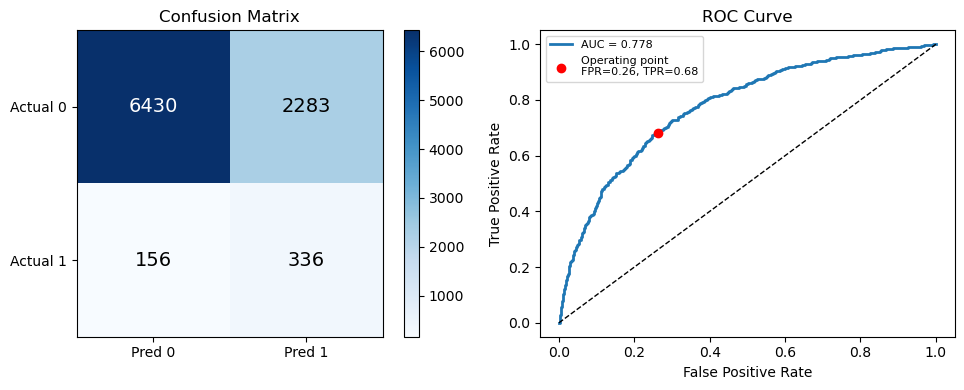

In [9]:
y_pred  = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
tpr = tp / (tp + fn)
fpr = fp / (fp + tn)
tnr = tn / (tn + fp)
ppv = tp / (tp + fp)

print("Confusion matrix:")
print(f"  {'':12s}  Pred 0   Pred 1")
print(f"  {'Actual 0':12s}  {tn:>6}   {fp:>6}   (specificity {tnr:.3f})")
print(f"  {'Actual 1':12s}  {fn:>6}   {tp:>6}   (sensitivity {tpr:.3f})")
print()
print(f"TPR (sensitivity):  {tpr:.3f}")
print(f"FPR (fall-out):     {fpr:.3f}")
print(f"Precision:          {ppv:.3f}")
print(f"ROC-AUC:            {roc_auc_score(y_test, y_proba):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=['Survived', 'Died']))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Pred 0', 'Pred 1'])
axes[0].set_yticklabels(['Actual 0', 'Actual 1'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)
axes[0].set_title('Confusion Matrix')
plt.colorbar(im, ax=axes[0])

fpr_curve, tpr_curve, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr_curve, tpr_curve, lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].scatter([fpr], [tpr], color='red', zorder=5, label=f'Operating point\nFPR={fpr:.2f}, TPR={tpr:.2f}')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve'); axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [10]:
coef_series = pd.Series(model.coef_[0], index=X.columns)
print("Top 20 POSITIVE coefficients:")
print(coef_series.sort_values(ascending=False).head(20).to_string())
print("\nTop 20 NEGATIVE coefficients:")
print(coef_series.sort_values(ascending=True).head(20).to_string())

Top 20 POSITIVE coefficients:
lab_sodium                                       0.460163
lab_h_missing                                    0.380021
hours_since_admission                            0.376192
drug_morphine_sulfate                            0.375665
anchor_age                                       0.300152
lab_ethanol                                      0.280484
drug_scopolamine_patch                           0.252764
lab_pco2                                         0.239768
drug_acetaminophen_iv                            0.218886
lab_anion_gap_missing                            0.216865
lab_free_kappa                                   0.192567
lab_lactate                                      0.183882
admission_type_EW EMER.                          0.182612
lab_blasts                                       0.181125
lab_potassium                                    0.171368
lab_chloride,_whole_blood_missing                0.167433
lab_ph_missing                            

## Lasso Path

[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   1 tasks      | elapsed:    6.7s
[Parallel(n_jobs=12)]: Done  11 out of  30 | elapsed:  2.2min remaining:  3.8min
[Parallel(n_jobs=12)]: Done  15 out of  30 | elapsed:  5.2min remaining:  5.2min
/nix/store/0wq9dh3n1nl2x4mx3ld8azmvpli7pk1l-python3-3.13.12-env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/nix/store/0wq9dh3n1nl2x4mx3ld8azmvpli7pk1l-python3-3.13.12-env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/nix/store/0wq9dh3n1nl2x4mx3ld8azmvpli7pk1l-python3-3.13.12-env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
[Parallel(n_job

Best C: 0.006210 (AUC: 0.8045)
Non-zero coefficients: 322 / 758


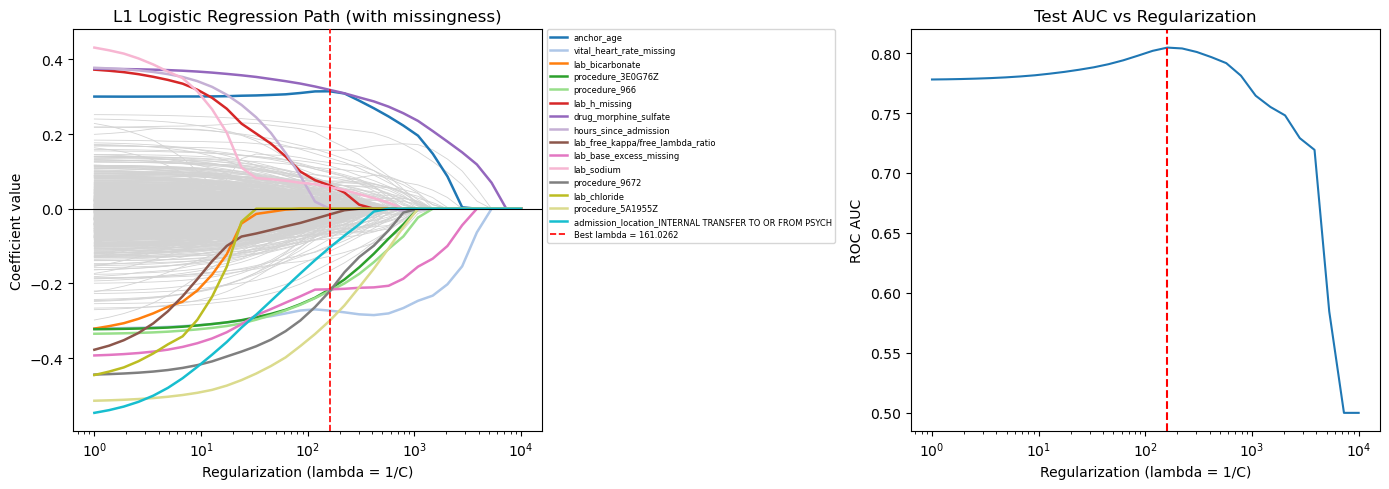

In [11]:
# Lasso path: fit individual models at 30 regularization strengths (parallelized)
from joblib import Parallel, delayed

Cs = np.logspace(-4, 0, 30)

def fit_one(C):
    lr = LogisticRegression(C=C, l1_ratio=1, solver='saga', max_iter=1000, class_weight='balanced')
    lr.fit(X_train_scaled, y_train)
    auc = roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:, 1])
    return lr.coef_[0], auc, lr

results = Parallel(n_jobs=12, verbose=10)(delayed(fit_one)(C) for C in Cs)
coefs_path, aucs, models = zip(*results)
coefs_path = np.array(coefs_path).T
aucs = np.array(aucs)

# Select best model by test AUC
best_idx = np.argmax(aucs)
best_C = Cs[best_idx]
model = models[best_idx]
print(f"Best C: {best_C:.6f} (AUC: {aucs[best_idx]:.4f})")
print(f"Non-zero coefficients: {np.sum(model.coef_[0] != 0)} / {len(model.coef_[0])}")

# --- Lasso path plot ---
alphas_plot = 1 / Cs
top_n = 15
top_idx = np.argsort(np.abs(coefs_path).max(axis=1))[-top_n:]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i in range(coefs_path.shape[0]):
    axes[0].plot(alphas_plot, coefs_path[i], color='lightgray', linewidth=0.6, zorder=1)

cmap = plt.cm.tab20
handles, labels = [], []
for rank, i in enumerate(top_idx):
    color = cmap(rank / top_n)
    line, = axes[0].plot(alphas_plot, coefs_path[i], color=color, linewidth=1.8, zorder=2)
    handles.append(line)
    labels.append(X.columns[i])

best_lambda = 1 / best_C
axes[0].axvline(best_lambda, color='red', linestyle='--', linewidth=1.2, zorder=3)
handles.append(plt.Line2D([0], [0], color='red', linestyle='--', linewidth=1.2))
labels.append(f'Best lambda = {best_lambda:.4f}')

axes[0].set_xscale('log')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Regularization (lambda = 1/C)')
axes[0].set_ylabel('Coefficient value')
axes[0].set_title('L1 Logistic Regression Path (with missingness)')
axes[0].legend(handles, labels, fontsize=6, loc='upper left',
               bbox_to_anchor=(1.01, 1), borderaxespad=0, frameon=True)

axes[1].plot(alphas_plot, aucs)
axes[1].axvline(best_lambda, color='red', linestyle='--')
axes[1].set_xscale('log')
axes[1].set_xlabel('Regularization (lambda = 1/C)')
axes[1].set_ylabel('ROC AUC')
axes[1].set_title('Test AUC vs Regularization')

plt.tight_layout()
plt.savefig('results/decompensation_lasso_path_missingness.png', dpi=120, bbox_inches='tight')
plt.show()

## Reload with Lasso-selected features only

In [12]:
# Extract nonzero features from best lasso model
coef_series = pd.Series(model.coef_[0], index=X.columns)
keep = coef_series[coef_series != 0].index.tolist()
all_feats = coef_series.index.tolist()
total_labs = sum(1 for f in all_feats if f.startswith('lab_') and not f.endswith('_missing'))
total_lab_miss = sum(1 for f in all_feats if f.startswith('lab_') and f.endswith('_missing'))
total_drugs = sum(1 for f in all_feats if f.startswith('drug_'))
total_procs = sum(1 for f in all_feats if f.startswith('procedure_'))
total_vitals = sum(1 for f in all_feats if f.startswith('vital_') and not f.endswith('_missing'))
total_vital_miss = sum(1 for f in all_feats if f.startswith('vital_') and f.endswith('_missing'))
total_other = len(all_feats) - total_labs - total_lab_miss - total_drugs - total_procs - total_vitals - total_vital_miss
print(f"Lasso selected {len(keep)} / {len(coef_series)} features")
print(f"  Labs: {sum(1 for f in keep if f.startswith('lab_') and not f.endswith('_missing'))} / {total_labs}")
print(f"  Lab missingness: {sum(1 for f in keep if f.startswith('lab_') and f.endswith('_missing'))} / {total_lab_miss}")
print(f"  Drugs: {sum(1 for f in keep if f.startswith('drug_'))} / {total_drugs}")
print(f"  Procedures: {sum(1 for f in keep if f.startswith('procedure_'))} / {total_procs}")
print(f"  Vitals: {sum(1 for f in keep if f.startswith('vital_') and not f.endswith('_missing'))} / {total_vitals}")
print(f"  Vital missingness: {sum(1 for f in keep if f.startswith('vital_') and f.endswith('_missing'))} / {total_vital_miss}")
print(f"  Other: {sum(1 for f in keep if not any(f.startswith(p) for p in ['lab_', 'drug_', 'procedure_', 'vital_']))} / {total_other}")

# Save for use in other notebooks (e.g. random forest)
pd.Series(keep).to_csv('results/lasso_selected_features_missingness.csv', index=False, header=False)
print(f"Saved to results/lasso_selected_features_missingness.csv")

Lasso selected 322 / 758 features
  Labs: 80 / 201
  Lab missingness: 38 / 121
  Drugs: 157 / 343
  Procedures: 33 / 54
  Vitals: 2 / 4
  Vital missingness: 1 / 1
  Other: 11 / 34
Saved to results/lasso_selected_features_missingness.csv


In [14]:
# Reload with more data, only loading Lasso-selected features
X, y, groups = DecompensationImputed.load_data(
    sample_size=100000, icu_vitals=True,
    top_n_labs=230, top_n_drugs=954, top_n_procedures=55,
    step_hours=48, keep_features=keep, missingness_indicators=True
)

X = X[[c for c in keep if c in X.columns]]
print(f"Final feature matrix: {X.shape}")

Sampled 58750 admissions (8750 deaths, 50000 survived)
Avg length of stay: 190.7 hours (7.9 days)
Generated 205098 windows from 58750 admissions (3.5 windows/admission)
Positive windows: 4373 (2.1322%)
  Labs filtered to 93 by keep_features
  Drugs filtered to 508 by keep_features
  Procedures filtered to 34 by keep_features
Cached to: decomp_rolling_n100000_v1_l230_d954_p55_o48_pred24_s48_kf336_miss
Returning 205098 windows with 406 features. y distribution:
y
0    0.978678
1    0.021322
Name: proportion, dtype: float64
Final feature matrix: (205098, 309)


In [15]:
# Re-split and re-scale with the larger dataset
unique_subjects = groups.unique()
np.random.seed(42)
np.random.shuffle(unique_subjects)
split = int(0.8 * len(unique_subjects))
train_subjects = set(unique_subjects[:split])
train_mask = groups.isin(train_subjects)

X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape} ({y_train.mean():.4%} positive)")
print(f"Test:  {X_test.shape} ({y_test.mean():.4%} positive)")

Train: (164223, 309) (2.1325% positive)
Test:  (40875, 309) (2.1309% positive)


In [16]:
# Refit with best C from lasso path on the larger, feature-reduced dataset
model = LogisticRegression(C=best_C, l1_ratio=1, solver='saga', max_iter=5000, class_weight='balanced')
model.fit(X_train_scaled, y_train)
print(f"Refit with C={best_C:.6f}, non-zero: {np.sum(model.coef_[0] != 0)} / {len(model.coef_[0])}")

Refit with C=0.006210, non-zero: 284 / 309


/nix/store/82d4idzilks59f2waanikzv3an5cn8q0-python3-3.13.12-env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [21]:
import joblib
joblib.dump(model, 'results/decompensation_lasso_model_missingness.joblib')

['results/decompensation_lasso_model_missingness.joblib']

In [22]:
coef_series = pd.Series(model.coef_[0], index=X.columns)
coef_series = coef_series.sort_values()
coef_series.to_csv('results/decompensation_coef_series_missingness.csv')

Confusion matrix:
                Pred 0   Pred 1
  Actual 0       32675     7329   (specificity 0.817)
  Actual 1         173      698   (sensitivity 0.801)

TPR (sensitivity):  0.801
FPR (fall-out):     0.183
Precision:          0.087
ROC-AUC:            0.889

              precision    recall  f1-score   support

    Survived       0.99      0.82      0.90     40004
        Died       0.09      0.80      0.16       871

    accuracy                           0.82     40875
   macro avg       0.54      0.81      0.53     40875
weighted avg       0.98      0.82      0.88     40875



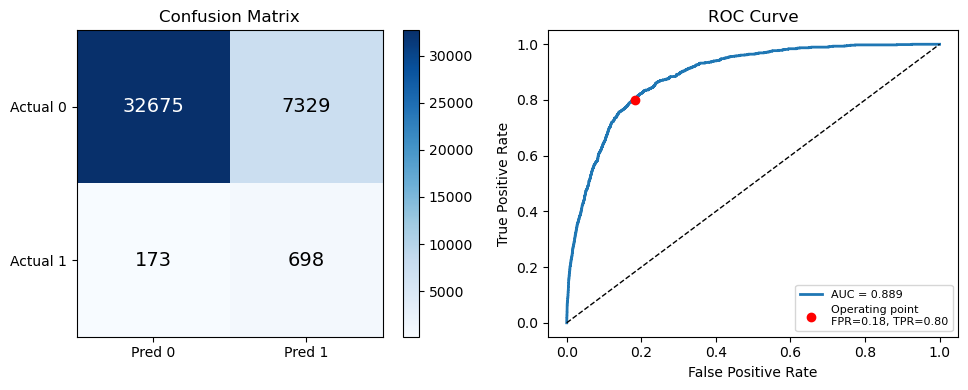

In [23]:
y_pred  = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
tpr = tp / (tp + fn)
fpr = fp / (fp + tn)
tnr = tn / (tn + fp)
ppv = tp / (tp + fp)

print("Confusion matrix:")
print(f"  {'':12s}  Pred 0   Pred 1")
print(f"  {'Actual 0':12s}  {tn:>6}   {fp:>6}   (specificity {tnr:.3f})")
print(f"  {'Actual 1':12s}  {fn:>6}   {tp:>6}   (sensitivity {tpr:.3f})")
print()
print(f"TPR (sensitivity):  {tpr:.3f}")
print(f"FPR (fall-out):     {fpr:.3f}")
print(f"Precision:          {ppv:.3f}")
print(f"ROC-AUC:            {roc_auc_score(y_test, y_proba):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=['Survived', 'Died']))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Pred 0', 'Pred 1'])
axes[0].set_yticklabels(['Actual 0', 'Actual 1'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)
axes[0].set_title('Confusion Matrix')
plt.colorbar(im, ax=axes[0])

fpr_curve, tpr_curve, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr_curve, tpr_curve, lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].scatter([fpr], [tpr], color='red', zorder=5, label=f'Operating point\nFPR={fpr:.2f}, TPR={tpr:.2f}')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve'); axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('results/decompensation_lasso_results_missingness.png', dpi=120, bbox_inches='tight')
plt.show()

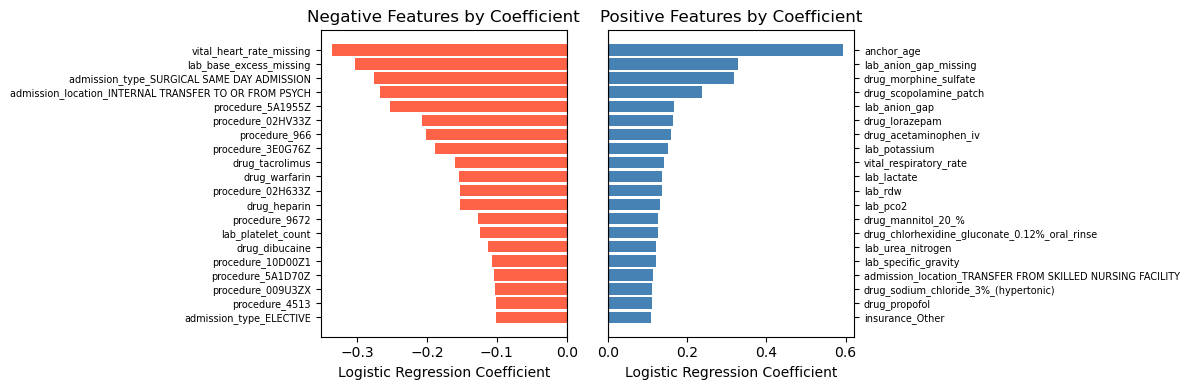

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

coef_series = pd.Series(model.coef_[0], index=X.columns)
top__neg_coef = coef_series[coef_series != 0].sort_values(ascending=True).head(20)
signed_top = coef_series[top__neg_coef.index]
axes[0].barh(signed_top.index[::-1], signed_top.values[::-1], color='tomato')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Logistic Regression Coefficient')
axes[0].set_title('Negative Features by Coefficient')
axes[0].tick_params(axis='y', labelsize=7)

coef_series = pd.Series(model.coef_[0], index=X.columns)
top_pos_coef = coef_series[coef_series != 0].sort_values(ascending=False).head(20)
signed_top = coef_series[top_pos_coef.index]
axes[1].barh(signed_top.index[::-1], signed_top.values[::-1], color='steelblue')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Logistic Regression Coefficient')
axes[1].set_title('Positive Features by Coefficient')
axes[1].tick_params(axis='y', labelsize=7)
axes[1].yaxis.set_label_position("right")
axes[1].yaxis.tick_right()

plt.tight_layout()
plt.show()

In [25]:
coef_series = pd.Series(model.coef_[0], index=X.columns)
print("Top 20 POSITIVE coefficients:")
print(coef_series.sort_values(ascending=False).head(20).to_string())
print("\nTop 20 NEGATIVE coefficients:")
print(coef_series.sort_values(ascending=True).head(20).to_string())

Top 20 POSITIVE coefficients:
anchor_age                                                   0.592355
lab_anion_gap_missing                                        0.326865
drug_morphine_sulfate                                        0.316716
drug_scopolamine_patch                                       0.236479
lab_anion_gap                                                0.167270
drug_lorazepam                                               0.163185
drug_acetaminophen_iv                                        0.157659
lab_potassium                                                0.152035
vital_respiratory_rate                                       0.140027
lab_lactate                                                  0.136531
lab_rdw                                                      0.136367
lab_pco2                                                     0.129934
drug_mannitol_20_%                                           0.126893
drug_chlorhexidine_gluconate_0.12%_oral_rinse               